# Importing all modules we need

In [1]:
import math

import pandas as pd
import os

# Loading all files we will need later on


In [2]:
path_fitts = os.path.join('results', 'fitts')
path_steering = os.path.join('results', 'steering')

files_fitts = [file for file in os.listdir(path_fitts) if file.endswith('.csv')]
files_steering = [file for file in os.listdir(path_steering) if file.endswith('.csv')]

dfs_fitts = []

for file in files_fitts:
    path = os.path.join(path_fitts, file)
    dfs_fitts.append(pd.read_csv(path))

df_fitts = pd.concat(dfs_fitts, ignore_index=True)

dfs_steering = []

for file in files_steering:
    path = os.path.join(path_steering, file)
    dfs_steering.append(pd.read_csv(path))

df_steering = pd.concat(dfs_steering, ignore_index=True)

In [3]:
print(df_fitts)

      iteration  part_id input_method  delay  num_targets  radius  distance  \
0             0  martina        mouse      0            8      25       350   
1             0  martina        mouse      0            8      25       350   
2             0  martina        mouse      0            8      25       350   
3             0  martina        mouse      0            8      25       350   
4             0  martina        mouse      0            8      25       350   
...         ...      ...          ...    ...          ...     ...       ...   
1039          2  martina     touchpad      0            8      55       550   
1040          2  martina     touchpad      0            8      55       550   
1041          2  martina     touchpad      0            8      55       550   
1042          2  martina     touchpad      0            8      55       550   
1043          2  martina     touchpad      0            8      55       550   

      target_id  hit      timestamp  
0            

In [4]:
df_steering

,iteration,part_id,input_method,delay,width,distance,errors,start_time,end_time
0,1,martina,mouse,0,100,400,0,1782830667733,1782830668186
1,2,martina,mouse,0,100,400,0,1782830669684,1782830670294
2,3,martina,mouse,0,100,400,0,1782830671763,1782830672402
3,1,martina,mouse,0,100,600,0,1782830655717,1782830656424
4,2,martina,mouse,0,100,600,0,1782830658106,1782830658661
...,...,...,...,...,...,...,...,...,...
103,2,martina,touchpad,0,60,600,2,1782830848755,1782830849894
104,3,martina,touchpad,0,60,600,0,1782830852075,1782830852974
105,1,martina,touchpad,0,60,800,0,1782830880746,1782830882044
106,2,martina,touchpad,0,60,800,0,1782830883947,1782830885355


In [5]:
fitts_runs_df = (
    df_fitts
    .groupby(
        [
            "part_id",
            "input_method",
            "delay",
            "radius",
            "distance",
            "iteration",
        ],
        as_index=False,
    )
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        num_clicks=("hit", "count"),
        num_hits = ("hit", "sum"),
        num_targets=("target_id", "count"),
    )
)

fitts_runs_df["duration_ms"] = (
    fitts_runs_df["end_time"] - fitts_runs_df["start_time"]
)

fitts_runs_df['accuracy'] = (
    fitts_runs_df['num_hits'] / fitts_runs_df['num_targets']
)

print(fitts_runs_df)

     part_id input_method  delay  radius  distance  iteration     start_time  \
0    martina        mouse      0      25       350          0  1782829503600   
1    martina        mouse      0      25       350          1  1782829509119   
2    martina        mouse      0      25       350          2  1782829514281   
3    martina        mouse      0      25       450          0  1782828967449   
4    martina        mouse      0      25       450          1  1782828974952   
..       ...          ...    ...     ...       ...        ...            ...   
103  martina     touchpad      0      55       450          1  1782829796376   
104  martina     touchpad      0      55       450          2  1782829802120   
105  martina     touchpad      0      55       550          0  1782829826005   
106  martina     touchpad      0      55       550          1  1782829831162   
107  martina     touchpad      0      55       550          2  1782829836229   

          end_time  num_clicks  num_hit

In [6]:
mean_df_fitts = (
    fitts_runs_df.groupby(
        ['part_id', 'input_method', 'delay', 'radius', 'distance'], as_index=False
    ).agg(
        mean_duration=("duration_ms", "mean"),
        mean_accuracy=("accuracy", "mean"),
    )
)

mean_df_fitts['mean_duration_seconds'] = (mean_df_fitts['mean_duration'] / 1000).round(2)
mean_df_fitts['no_errors'] = mean_df_fitts['mean_accuracy'] == 1

In [7]:
print(mean_df_fitts)

    part_id input_method  delay  radius  distance  mean_duration  \
0   martina        mouse      0      25       350    4141.666667   
1   martina        mouse      0      25       450    4983.000000   
2   martina        mouse      0      25       550    4738.000000   
3   martina        mouse      0      40       350    3418.666667   
4   martina        mouse      0      40       450    4166.333333   
5   martina        mouse      0      40       550    4031.333333   
6   martina        mouse      0      55       350    2692.000000   
7   martina        mouse      0      55       450    3202.000000   
8   martina        mouse      0      55       550    3559.666667   
9   martina        mouse    150      25       350    4923.333333   
10  martina        mouse    150      25       450    5779.000000   
11  martina        mouse    150      25       550    5848.666667   
12  martina        mouse    150      40       350    4220.000000   
13  martina        mouse    150      40       45

In [8]:
mean_fitts_combined = mean_df_fitts.groupby(
    ['part_id', 'input_method', 'delay'], as_index=False
).agg(
    total_mean_duration=("mean_duration_seconds", "mean"),
    total_mean_accuracy=("mean_accuracy", "mean"),
    total_no_errors=("no_errors", "sum")
)

print(mean_fitts_combined)

   part_id input_method  delay  total_mean_duration  total_mean_accuracy  \
0  martina        mouse      0             3.881111             0.963786   
1  martina        mouse    150             5.663333             0.938047   
2  martina         pose      0            14.146667             0.674068   
3  martina     touchpad      0             4.504444             0.984362   

   total_no_errors  
0                4  
1                1  
2                0  
3                6  


In [9]:
mean_fitts_final = mean_fitts_combined.groupby(
    ['input_method', 'delay'], as_index=False
).agg(
    mean_duration=("total_mean_duration", "mean"),
    mean_accuracy=("total_mean_accuracy", "mean"),
)
mean_fitts_final['mean_duration'] = mean_fitts_final['mean_duration'].round(2)
print(mean_fitts_final)

  input_method  delay  mean_duration  mean_accuracy
0        mouse      0           3.88       0.963786
1        mouse    150           5.66       0.938047
2         pose      0          14.15       0.674068
3     touchpad      0           4.50       0.984362


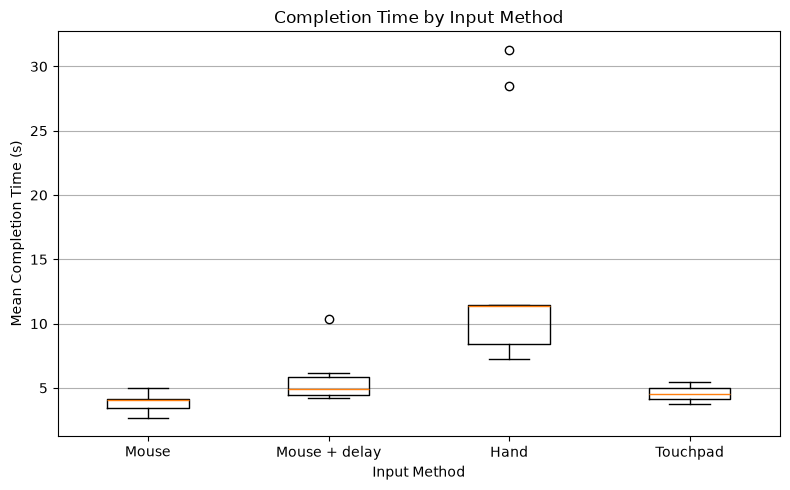

In [10]:
import matplotlib.pyplot as plt

plot_data = {
    "Mouse": mean_df_fitts[
        (mean_df_fitts["input_method"] == "mouse") &
        (mean_df_fitts["delay"] == 0)
    ]["mean_duration_seconds"],

    "Mouse + delay": mean_df_fitts[
        (mean_df_fitts["input_method"] == "mouse") &
        (mean_df_fitts["delay"] > 0)
    ]["mean_duration_seconds"],

    "Hand": mean_df_fitts[
        mean_df_fitts["input_method"] == "pose"
    ]["mean_duration_seconds"],

    "Touchpad": mean_df_fitts[
        mean_df_fitts["input_method"] == "touchpad"
    ]["mean_duration_seconds"],
}

plt.figure(figsize=(8, 5))
plt.boxplot(plot_data.values(), tick_labels=plot_data.keys())
plt.title("Completion Time by Input Method")
plt.xlabel("Input Method")
plt.ylabel("Mean Completion Time (s)")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

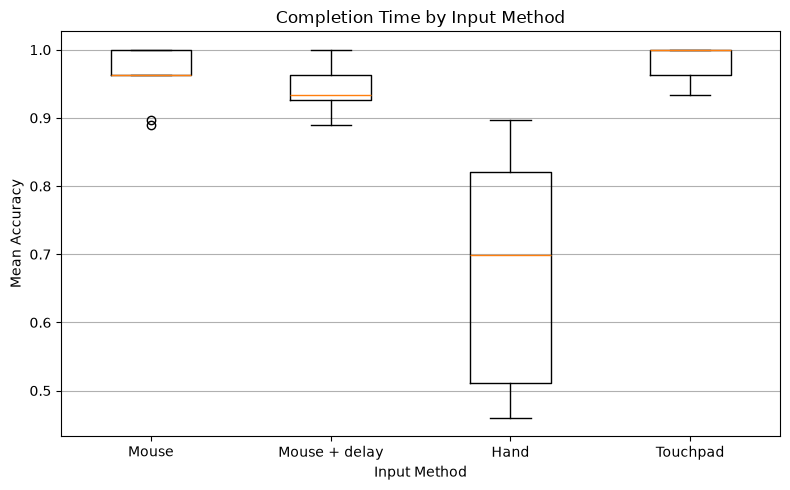

In [11]:
import matplotlib.pyplot as plt

plot_data = {
    "Mouse": mean_df_fitts[
        (mean_df_fitts["input_method"] == "mouse") &
        (mean_df_fitts["delay"] == 0)
    ]["mean_accuracy"],

    "Mouse + delay": mean_df_fitts[
        (mean_df_fitts["input_method"] == "mouse") &
        (mean_df_fitts["delay"] > 0)
    ]["mean_accuracy"],

    "Hand": mean_df_fitts[
        mean_df_fitts["input_method"] == "pose"
    ]["mean_accuracy"],

    "Touchpad": mean_df_fitts[
        mean_df_fitts["input_method"] == "touchpad"
    ]["mean_accuracy"],
}

plt.figure(figsize=(8, 5))
plt.boxplot(plot_data.values(), tick_labels=plot_data.keys())
plt.title("Completion Time by Input Method")
plt.xlabel("Input Method")
plt.ylabel("Mean Accuracy")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [12]:
print(df_steering)

     iteration  part_id input_method  delay  width  distance  errors  \
0            1  martina        mouse      0    100       400       0   
1            2  martina        mouse      0    100       400       0   
2            3  martina        mouse      0    100       400       0   
3            1  martina        mouse      0    100       600       0   
4            2  martina        mouse      0    100       600       0   
..         ...      ...          ...    ...    ...       ...     ...   
103          2  martina     touchpad      0     60       600       2   
104          3  martina     touchpad      0     60       600       0   
105          1  martina     touchpad      0     60       800       0   
106          2  martina     touchpad      0     60       800       0   
107          3  martina     touchpad      0     60       800       0   

        start_time       end_time  
0    1782830667733  1782830668186  
1    1782830669684  1782830670294  
2    1782830671763  1782830

In [13]:
df_steering['duration'] = ((df_steering['end_time'] - df_steering['start_time']) / 1000).round(2)

df_steering_iterations = df_steering.groupby(
    ['part_id', 'input_method', 'delay', 'width', 'distance'], as_index=False
).agg(
    mean_duration=("duration", "mean"),
    total_errors=('errors', 'sum')
)

df_steering_iterations['error_rate'] = df_steering_iterations['total_errors'] / 3


In [14]:
print(df_steering_iterations)

    part_id input_method  delay  width  distance  mean_duration  total_errors  \
0   martina        mouse      0     60       400       0.550000             0   
1   martina        mouse      0     60       600       0.826667             0   
2   martina        mouse      0     60       800       1.153333             0   
3   martina        mouse      0    100       400       0.566667             0   
4   martina        mouse      0    100       600       0.613333             0   
5   martina        mouse      0    100       800       0.866667             0   
6   martina        mouse      0    140       400       0.590000             0   
7   martina        mouse      0    140       600       1.183333             1   
8   martina        mouse      0    140       800       0.623333             0   
9   martina        mouse    150     60       400       0.620000             0   
10  martina        mouse    150     60       600       0.916667             0   
11  martina        mouse    

In [15]:
df_steering_combined = df_steering_iterations.groupby(
    ['input_method', 'delay'], as_index=False
).agg(
    total_errors=("total_errors", "sum"),
    mean_error_rate=("error_rate", "mean"),
    mean_duration=('mean_duration', 'mean')
)

In [16]:
print(df_steering_combined)

  input_method  delay  total_errors  mean_error_rate  mean_duration
0        mouse      0             1         0.037037       0.774815
1        mouse    150             0         0.000000       0.785185
2         pose      0             1         0.037037       1.656296
3     touchpad      0             4         0.148148       0.697407


In [17]:
df_steering_participants = df_steering_iterations.groupby(
    ['part_id', 'input_method', 'delay'], as_index=False
).agg(
    total_errors=("total_errors", "sum"),
    mean_error_rate=("error_rate", "mean"),
    mean_duration=('mean_duration', 'mean')
)

In [18]:
print(df_steering_participants)

   part_id input_method  delay  total_errors  mean_error_rate  mean_duration
0  martina        mouse      0             1         0.037037       0.774815
1  martina        mouse    150             0         0.000000       0.785185
2  martina         pose      0             1         0.037037       1.656296
3  martina     touchpad      0             4         0.148148       0.697407


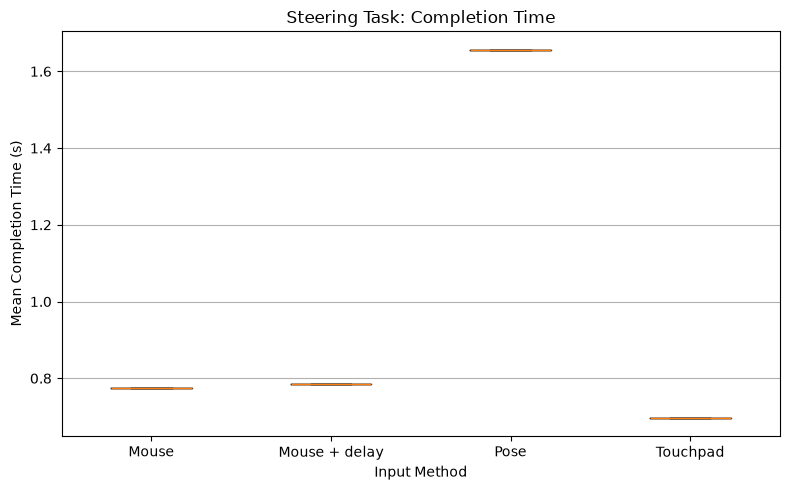

In [19]:
import matplotlib.pyplot as plt

plot_data = {
    "Mouse": df_steering_participants[
        (df_steering_participants["input_method"] == "mouse") &
        (df_steering_participants["delay"] == 0)
    ]["mean_duration"],

    "Mouse + delay": df_steering_participants[
        (df_steering_participants["input_method"] == "mouse") &
        (df_steering_participants["delay"] > 0)
    ]["mean_duration"],

    "Pose": df_steering_participants[
        df_steering_participants["input_method"] == "pose"
    ]["mean_duration"],

    "Touchpad": df_steering_participants[
        df_steering_participants["input_method"] == "touchpad"
    ]["mean_duration"],
}

plt.figure(figsize=(8, 5))
plt.boxplot(plot_data.values(), tick_labels=plot_data.keys())

plt.title("Steering Task: Completion Time")
plt.xlabel("Input Method")
plt.ylabel("Mean Completion Time (s)")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

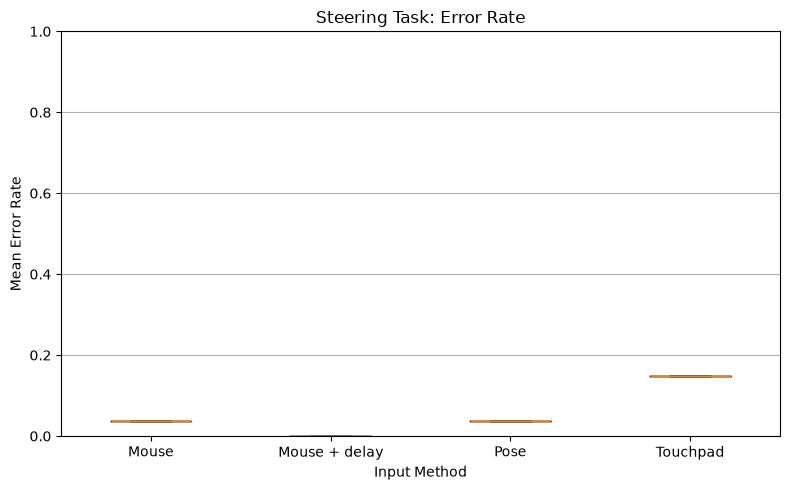

In [20]:
import matplotlib.pyplot as plt

plot_data = {
    "Mouse": df_steering_participants[
        (df_steering_participants["input_method"] == "mouse") &
        (df_steering_participants["delay"] == 0)
    ]["mean_error_rate"],

    "Mouse + delay": df_steering_participants[
        (df_steering_participants["input_method"] == "mouse") &
        (df_steering_participants["delay"] > 0)
    ]["mean_error_rate"],

    "Pose": df_steering_participants[
        df_steering_participants["input_method"] == "pose"
    ]["mean_error_rate"],

    "Touchpad": df_steering_participants[
        df_steering_participants["input_method"] == "touchpad"
    ]["mean_error_rate"],
}

plt.figure(figsize=(8, 5))
plt.boxplot(plot_data.values(), tick_labels=plot_data.keys())

plt.title("Steering Task: Error Rate")
plt.xlabel("Input Method")
plt.ylabel("Mean Error Rate")
plt.ylim(0, 1)
plt.grid(axis="y")

plt.tight_layout()
plt.show()